In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
#from scipy.stats import entropy
#from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
#import diptest


# Two Channels of Home-Court Advantage: NBA Close Games as a Testbed

## 1. Abstract

This study examines whether home court referee bias in NBA close games is reflected in betting market outcomes. Using NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M] as ground truth for referee error direction, we first replicate and extend the methodology of Pelechrinis (2023) [PelechrinisL2M] across three periods defined by crowd presence conditions: Pre-COVID (2015–2019), COVID (2020–2022), and Post-COVID (2023–2025). Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric and linked to pre-game point spreads and cover outcomes from independent bookmakers [KaggleBetting]. The central question is whether the betting market efficiently prices home-court advantage in close games — tested through the home team cover rate across three temporal periods defined by crowd presence conditions. The COVID-19 period, during which games were played without fans, serves as a natural experiment for isolating the crowd pressure mechanism.


## 2. Introduction
Referee decisions in professional sports are not made in a vacuum. Research has documented systematic patterns in how referees make errors — favoring home teams [ErikstadJohansen2020] and higher-status players [Barrett2021]. This study examines whether these patterns are detectable not only in officiating data, but in the outcomes of betting markets as well.

### 2.1 Background

Home court bias is the most studied form of referee bias in professional sports. Crowd noise and social pressure from home fans have been linked to systematic differences in foul calls favoring the home team [ErikstadJohansen2020]. In the NBA specifically, Pelechrinis (2023) showed that this effect disappears when games are played without fans [PelechrinisL2M] — a strong indicator that the crowd, not the home team itself, is the driving factor.

The COVID-19 pandemic (seasons 2020–2022), during which NBA games were played without fans or with severely restricted attendance, provides a natural experiment within the dataset. If bias is driven by social pressure, it should diminish during this period — a prediction that is directly testable with the available data.

We extend this logic to the betting market. A full arena exerts direct social pressure on referees in real-time. The betting market reflects a different but related force — the collective expectations of a much wider audience, priced into the spread before tip-off. Referee bias is reactive; market pricing is inertial. Both are independent signals of the same structural phenomenon: the systematic overestimation of home-court advantage in high-stakes close games.

### 2.2 Related Work
Belasen et al. (2025) examine the same L2M data and find that referees make significantly fewer incorrect calls against underdogs than against favorites — suggesting that betting market status is associated with the direction of referee errors [BelasenL2M2025]. This study approaches the question from a complementary direction: rather than testing whether market expectations predict referee errors, we test whether referee errors predict betting outcomes.

### 2.3 Research Design

To examine Structural Convergence, two independent data sources are used.

**RQ1 — The Reactive Channel**: Do referee errors in NBA close games systematically favour the home team, and does this effect vary with crowd presence? The primary dataset is the NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M], which provide a unique ground truth — every referee decision in the final two minutes of close games is graded as correct or incorrect by the NBA league office. Referee errors are aggregated to the game level via the Net Whistle Gain (NWG) metric.

**RQ2 — The Inertial Channel**: Does the betting market systematically misprice home-court advantage in close games? Betting market data [KaggleBetting] provides pre-game point spreads and post-game cover outcomes set by independent bookmakers with no access to L2M grades. The home team cover rate is examined across three temporal periods defined by crowd presence conditions.



## 3. Methodology & Hypotheses

### 3.1 The Logic of Structural Convergence

Home-court advantage manifests through two independent channels — a Reactive Channel (social pressure on referees) and an Inertial Channel (collective belief in market pricing). We do not hypothesize a causal link between the two signals. Since spreads are set before the game, bookmakers cannot observe NWG at the time of pricing. Structural Convergence requires only that both signals consistently point in the same direction.

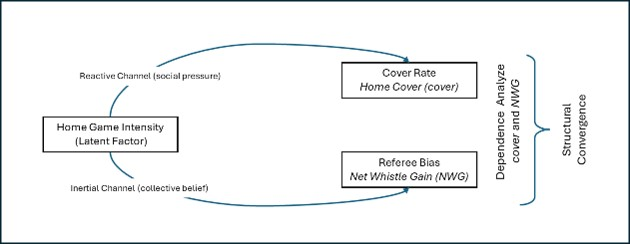   
*Fig. 1 — The Structural Convergence Framework*

### 3.2 Key Variables & Definitions

Before formalizing the hypotheses, we define the two primary metrics used throughout the analysis.

**Net Whistle Gain (NWG)** — the net difference between referee errors favouring the home team and referee errors favouring the away team in the final two minutes of a close game. A positive NWG indicates realized referee bias toward the home team. Formally:

$$\beta = |\{ \text{INC} : \text{committing\_side} = \text{home} \}| + |\{ \text{IC} : \text{disadvantaged\_side} = \text{home} \}|$$

$$\delta = |\{ \text{INC} : \text{disadvantaged\_side} = \text{home} \}| + |\{ \text{IC} : \text{committing\_side} = \text{home} \}|$$

$$NWG = \beta - \delta$$

**Cover Rate** — a binary outcome indicating whether the home team beat the point spread set by bookmakers before the game:

$$\text{cover} = \begin{cases} 1 & \text{if home team beat the spread} \\ 0 & \text{if home team did not beat the spread} \\ \text{excluded} & \text{if margin} = \text{spread (push)} \end{cases}$$

### 3.3 Formal Statistical Framework

#### 3.3.1 RQ1 — The Reactive Channel

Does home-court referee bias exist in the data, and does it vary with crowd presence? Following Pelechrinis (2023) [PelechrinisL2M], we adopt a one-tailed test:

$$H_0^{RQ1}: E[NWG] \leq 0 \quad \text{(no systematic home-court referee bias)}$$

$$H_1^{RQ1}: E[NWG] > 0 \quad \text{(referee errors systematically favour the home team)}$$

The empirical p-value is defined as:

$$p = \frac{|\{t_{sim} \geq t_{real}\}|}{n_{sim}}$$

where $t_{real}$ is the observed sum of NWG and $t_{sim}$ is the simulated sum under $H_0^{RQ1}$, generated via Monte Carlo simulation following Pelechrinis (2023) [PelechrinisCode]. The test is conducted across three periods defined by crowd presence conditions:

- **Pre-COVID** (2015–2019): Full capacity arenas.
- **COVID** (2020–2022): Restricted or no attendance — natural experiment.
- **Post-COVID** (2023–2025): Full capacity arenas restored.

#### 3.3.2 RQ2 — The Inertial Channel

Does the betting market systematically misprice home-court advantage in close games? Throughout this study, *cover* refers exclusively to the home team covering the spread (see Glossary, Section 3.6). We adopt a two-sided test:

$$H_0^{RQ2}: P(\text{home\_cover}) = 0.50 \quad \text{(the market efficiently prices home-court advantage)}$$

$$H_1^{RQ2}: P(\text{home\_cover}) \neq 0.50 \quad \text{(the market systematically misprices home-court advantage)}$$

The test is conducted via a two-sided binomial test across the same three temporal periods.

### 3.4 Variables

For each game we measure the following variables.

**Whistle Benefit ($\beta$)** — the count of referee errors favouring the home team at the play level. For each graded play, the committing side identifies the team committing the infraction and the disadvantaged side identifies the team disadvantaged by it. These two fields operationalise $\beta$ and $\delta$ as defined in Section 3.2.

**Whistle Detriment ($\delta$)** — the count of referee errors favouring the away team at the play level. Formally defined in Section 3.2.

**Net Whistle Gain ($NWG$)** — the primary test statistic for $H_0^{RQ1}$ in Section 3.3.1. Grouped into three categories for exploratory analysis: $NWG < 0$ (away bias), $NWG = 0$ (no bias), $NWG > 0$ (home bias). Formally defined in Section 3.2.

**Asymmetry Ratio ($AR$)** — an alternative expression of $NWG$ as a proportion. Undefined when $\beta + \delta = 0$. Formally defined in Section 3.2.

**Point Spread** — pre-game market expectation of the home team's margin, used in the construction of the cover outcome variable.

**Cover Outcome** — the primary test statistic for $H_0^{RQ2}$ in Section 3.3.2. Binary outcome indicating whether the home team beat the spread. Pushes are excluded.

**Control Variables** — season, temporal period (Pre-COVID / COVID / Post-COVID), playoff status, and attendance as a proxy for crowd pressure.

### 3.5 Assumptions

1. L2M grades are treated as ground truth for referee error classification.
2. Errors are independent across plays within a game.
3. The three periods (Pre-COVID, COVID, Post-COVID) are structurally distinct with respect to crowd presence conditions — this assumption is tested empirically in Section 7.2.
4. Betting lines are set before the game with no access to L2M data — bookmakers cannot observe referee errors at the time of line setting.
5. CNC decisions are excluded — their grading criteria changed across seasons [PelechrinisL2M].
6. This study does not test real-time market efficiency. $NWG$ is a post-game measure and cannot be used as a trading signal. Structural Convergence requires only that both signals consistently point in the same direction — not that one predicts the other.

All tests are conducted at $\alpha = 0.05$.

### 3.6 Glossary

**Point Spread** — Pre-game margin set by bookmakers. Example: Lakers $-5.5$ must win by 6+ points to cover.

**Cover** — A team covers when they beat the bookmaker's margin. Throughout this study, *cover* refers exclusively to the home team covering the spread. The favourite covers by winning by more than the spread; the underdog covers by losing by less (or winning outright). Pushes are excluded from all cover rate calculations.

**Push** — Final margin equals the spread exactly. No winner — stakes returned. Pushes are excluded from cover rate calculations.

**INC (Incorrect Non-Call)** — A violation occurred but was not called. Example: a clear push-off goes uncalled in the final minute.

**IC (Incorrect Call)** — A call was made but no violation occurred. Example: a foul is called on a defender who did not make contact.

**L2M Report** — Official NBA post-game grading of every referee decision in the final two minutes of close games. Published since March 2015.

**NWG (Net Whistle Gain)** — Net referee errors favouring the home team. Positive = home bias; negative = away bias; zero = no bias. Formally defined in Section 3.2.

**AR (Asymmetry Ratio)** — NWG expressed as a proportion: $AR = 0.5$ indicates no bias; $AR > 0.5$ indicates home bias; $AR < 0.5$ indicates away bias. Undefined when $\beta + \delta = 0$. Formally defined in Section 3.2.

**Market Mispricing** — The systematic deviation of the home team cover rate from 50% in close games, as tested via $H_0^{RQ2}$.

**Structural Convergence** — The hypothesis that two independent signals — NWG and cover rate — consistently point in the same direction, without requiring a causal link between them. Full convergence requires both channels to reject their respective null hypotheses; partial convergence is observed when only one channel rejects.

## 4. Initial Data Analysis (IDA)

This study draws on two independently collected datasets. The first is the NBA Last Two Minute (L2M) reports [AtlhawksfanaticL2M], selected as the primary source for referee error classification because it provides official NBA grading of every decision in the final two minutes of close games.  

The second is the NBA betting dataset [KaggleBetting], selected as an independent source for market pricing data covering the same period. The two datasets are analyzed separately before being merged into a single game-level master dataset.

### 4.1 NBA Last Two Minute Reports (L2M)

#### 4.1.1 Dataset Overview

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. A Last Two Minute Report is a play-by-play grading of all calls and material non-calls in the last two minutes of the fourth quarter or the last two minutes of any overtime period, for all games that were within 5 points at that stage. The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones, supplemented with box score data from stats.nba.com which adds attendance and player minutes [AtlhawksfanaticL2M]. The full list of variables is described in the README of [AtlhawksfanaticL2M].

#### 4.1.2 Data Quality

##### Shape

The dataset dimensions are inspected to confirm that the file was read correctly.

In [3]:
nba_data = pd.read_csv('data/input/L2M_stats_nba.zip', low_memory=False)

print(nba_data.head())
# Shape
print('Shape:', nba_data.shape)

  period     time         call_type decision  \
0     Q4  01:52.0    Foul: Shooting      CNC   
1     Q4  01:43.0    Foul: Shooting       CC   
2     Q4  01:32.0    Foul: Shooting       CC   
3     Q4  01:09.0  Foul: Loose Ball       CC   
4     Q4  00:53.0    Foul: Shooting      CNC   

                         game_details  page                    file  \
0  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
1  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
2  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
3  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   
4  Cavaliers @ Rockets (Mar 01, 2015)   1.0  L2M-CLE-HOU-3-1-15.pdf   

      game_date  away_team home_team  ... committing_min committing_team  \
0  Mar 01, 2015  Cavaliers   Rockets  ...      30.950000             HOU   
1  Mar 01, 2015  Cavaliers   Rockets  ...      50.800000             CLE   
2  Mar 01, 2015  Cavaliers   Rockets  ...      42.233333

The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. It is fully described in the README of [AtlhawksfanaticL2M]. Based on the source documentation, the following columns are identified as candidates for analysis.

##### Data Types

Inspecting the type of each column identifies potential parsing issues. Dates stored as strings or booleans stored as objects will require conversion before analysis.

In [4]:
dtype_groups = nba_data.dtypes.reset_index()
dtype_groups.columns = ['column', 'dtype']
for dtype, group in dtype_groups.groupby('dtype'):
    print(f"\n{dtype}:")
    for col in group['column']:
        print(f"  {col}")


bool:
  playoff

int64:
  gid
  home_score
  away_score
  season
  time_min

float64:
  page
  game_id
  ImposibleIndicator
  VideolLink
  Qualifier
  posID
  posTeamId
  teamIdInFavor
  errorInFavor
  imgChart
  GameId
  HomeTeamId
  AwayTeamId
  GAME_ID
  ATTENDANCE
  committing_min
  disadvantaged_min
  time_sec
  time2

object:
  period
  time
  call_type
  decision
  game_details
  file
  game_date
  away_team
  home_team
  date
  call
  type
  home
  away
  gcode
  national_tv
  networks
  PCTime
  Difficulty
  posStart
  posEnd
  GameDate
  L2M_Comments
  committing_team
  committing_side
  disadvantaged_team
  disadvantaged_side
  type2


> **Data Types** --- All 53 columns are inspected for parsing issues. A full description of each column is available in the source documentation [AtlhawksfanaticL2M]. Key columns have the expected types: `playoff` is `bool`, `season` and `ATTENDANCE` are numeric, and categorical columns (decision, committing_side, disadvantaged_side, call_type, period) are object, consistent with string-encoded categorical variables in pandas. Three columns require conversion before analysis: `date`, `game_date`, and `GameDate` are stored as `object` and require datetime conversion. `GAME_ID` is `float64` but represents integer game IDs. Columns originating from the official NBA API are not applicable for PDF-sourced games and their missingness is examined in the following section. Columns containing personal information --- player names and referee identities --- have been excluded on ethical grounds and are therefore absent from the dataset. All conversions will be performed in the Tidy Data Preparation section.

##### Missing Values

Columns with missing values are identified and quantified. The source and treatment of each missing value group is examined before any imputation or exclusion decision is made.

In [5]:
missing = nba_data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(f"\n{missing.to_string()}")

Columns with missing values: 34

Qualifier             90302
teamIdInFavor         90302
errorInFavor          90302
L2M_Comments          89809
networks              88993
game_details          58270
page                  58270
Difficulty            34148
GameDate              32032
HomeTeamId            32032
posID                 32032
posStart              32032
ImposibleIndicator    32032
VideolLink            32032
posEnd                32032
posTeamId             32032
PCTime                32032
game_id               32032
AwayTeamId            32032
imgChart              32032
GameId                32032
disadvantaged_min     11681
ATTENDANCE             6509
disadvantaged_team     5801
disadvantaged_side     5801
committing_min         3183
decision               2502
committing_side        2433
committing_team        2433
GAME_ID                 631
call_type                48
call                     48
type                     48
type2                    48


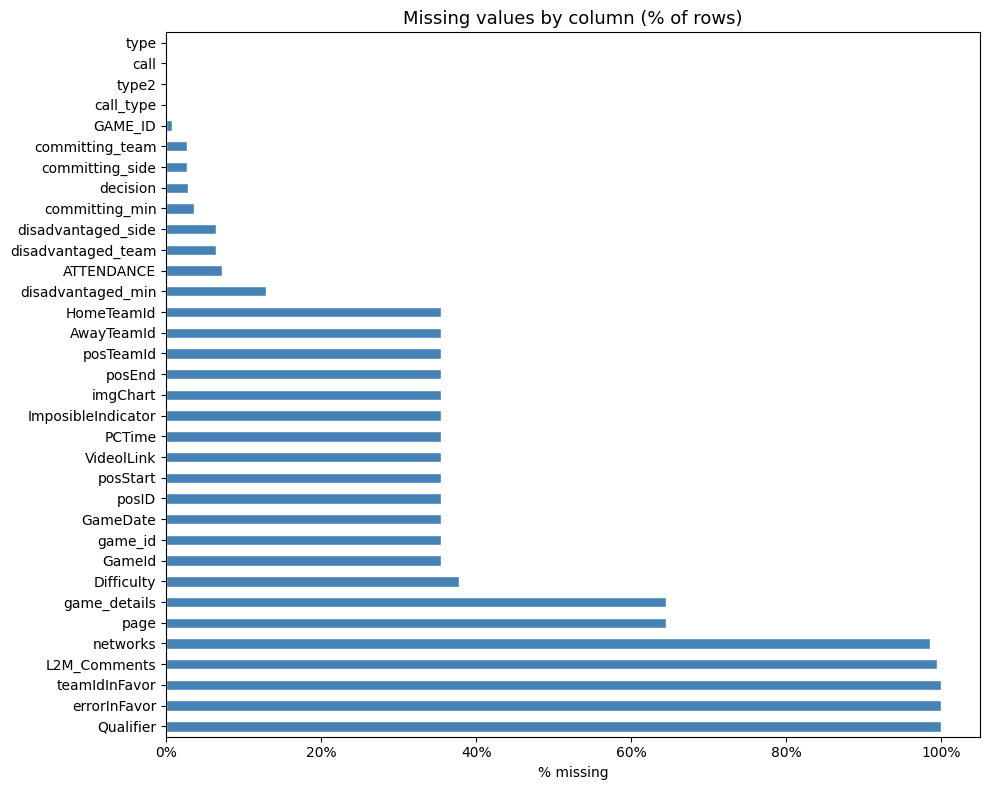

Columns with missing values: 34 / 53


In [6]:
# Missing values by column
missing = nba_data.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 8))
missing.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Missing values by column (% of rows)', fontsize=13)
ax.set_xlabel('% missing')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

print(f"Columns with missing values: {len(missing)} / {len(nba_data.columns)}")

**Missing Values** --- Missing values are identified across all columns and fall into three categories.

* **Expected and structural:** `game_details` and `page` have 58,270 missing values each --- absent for all API-sourced games. `Qualifier`, `teamIdInFavor`, `errorInFavor`, `L2M_Comments`, and `networks` are largely or entirely missing and are not used in the analysis. `game_id`, `PCTime`, `ImposibleIndicator`, `VideolLink`, `posID`, `posStart`, `posEnd`, `posTeamId`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, and `AwayTeamId` have exactly 32,032 missing values each --- corresponding to PDF-sourced games for which the API data is not available.

* **Require attention:** `decision` has 2,502 missing values representing plays not detectable without technology, excluded from analysis following Pelechrinis (2023) [PelechrinisL2M]. `committing_side` and `committing_team` have 2,433 missing values each, while `disadvantaged_side` and `disadvantaged_team` have 5,801 --- these are critical for $\beta$ and $\delta$ calculations and are examined in the Tidy Data Preparation section. `ATTENDANCE` has 6,509 missing values. `GAME_ID` has 631 missing values.

* **Known data quality issues:** `call_type`, `call`, `type`, and `type2` share 48 missing values --- the same rows. `committing_min` has 3,183 missing values and `disadvantaged_min` has 11,681, partly due to NBA input errors [AtlhawksfanaticL2M]. The treatment of all remaining missing values is deferred to the Tidy Data Preparation section.

##### Duplicates

Duplicate rows are identified to assess data integrity.

In [7]:
print(f"Duplicate rows: {nba_data.duplicated().sum()}")
print(f"Total rows: {len(nba_data)}")

Duplicate rows: 58
Total rows: 90302


> **Duplicates** --- The dataset contains 58 duplicate rows out of 90,302, corresponding to less than $0.1\%$ of the data. These are examined at the raw dataset level only. After column selection in the Tidy Data Preparation section, additional duplicates may emerge as a result of dropping identifying columns --- this will be re-examined after tidying.

In [8]:
# Cardinality check for all columns
print("=== Cardinality Analysis ===")
print(f"{'Field':<30} {'Unique':>8}  {'Type':<10}  Sample values")
print("-" * 80)
for col in sorted(nba_data.columns):
    n = nba_data[col].nunique()
    dtype = str(nba_data[col].dtype)
    vals = nba_data[col].dropna().unique()
    sample = sorted([str(v) for v in vals if str(v) != 'nan'])[:4]
    print(f"  {col:<28} {n:>6}  {dtype:<10}  {sample}")

=== Cardinality Analysis ===
Field                            Unique  Type        Sample values
--------------------------------------------------------------------------------
  ATTENDANCE                     2175  float64     ['0.0', '1000.0', '10079.0', '1008.0']
  AwayTeamId                       30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  Difficulty                        5  object      ['Blatant/Hard', 'Difficult', 'Observable', 'Technical']
  GAME_ID                        4454  float64     ['12000007.0', '12100023.0', '21400880.0', '21400883.0']
  GameDate                       2101  object      ['2019-01-01T00:00:00', '2019-01-02T00:00:00', '2019-01-03T00:00:00', '2019-01-04T00:00:00']
  GameId                         2810  float64     ['12000007.0', '12100023.0', '21800552.0', '21800561.0']
  HomeTeamId                       30  float64     ['1610612737.0', '1610612738.0', '1610612739.0', '1610612740.0']
  ImposibleIndicator             

> **Cardinality Analysis**
>
> **Core analytical fields** — `decision` contains exactly 4 values (CC, CNC, IC, INC) with no formatting inconsistencies, ensuring exact NWG aggregation. `committing_side` and `disadvantaged_side` are strictly binary (home/away), confirming a clean Home vs Away model.
>
> **Game identification fields** — `playoff` is strictly binary, `season` covers exactly 11 seasons (2015–2025), and `gid` has 4,487 unique values consistent with the expected number of close games.
>
> **Temporal fields** — `period` contains 5 values (Q4–Q7): Q4 is the standard final regulation period while Q5–Q7 represent overtime periods, capturing the highest-intensity game conclusions where structural convergence is most likely to occur.
>
> **Empty and zero-variance fields** — `Qualifier`, `teamIdInFavor`, and `errorInFavor` have zero unique values, justifying manual NWG calculation via `decision` and `side` rather than relying on missing pre-computed columns. `ImposibleIndicator` has a single value (0.0) and is excluded as a zero-variance field.

#### 4.1.3 Column-Level Analysis

The dataset contains 53 columns after removal of personal identifiers. Based on the source documentation [AtlhawksfanaticL2M] and the research questions defined in Section 3, a subset of columns is identified as candidates for analysis. The following sections examine each column group in detail, with the goal of determining which columns are suitable for inclusion in the final analytical dataset.

Column redundancy is assessed using the chi-squared test of independence for categorical columns and exact match rate where two columns represent the same value in different formats. Coverage analysis (% non-null) identifies structurally incomplete columns. A statistically significant chi-squared result indicates that two columns are associated — the stronger the association, the more redundant the columns are.

In [9]:
print(sorted(nba_data.columns.tolist(), key=str.lower))

['ATTENDANCE', 'away', 'away_score', 'away_team', 'AwayTeamId', 'call', 'call_type', 'committing_min', 'committing_side', 'committing_team', 'date', 'decision', 'Difficulty', 'disadvantaged_min', 'disadvantaged_side', 'disadvantaged_team', 'errorInFavor', 'file', 'game_date', 'game_details', 'game_id', 'GAME_ID', 'GameDate', 'GameId', 'gcode', 'gid', 'home', 'home_score', 'home_team', 'HomeTeamId', 'imgChart', 'ImposibleIndicator', 'L2M_Comments', 'national_tv', 'networks', 'page', 'PCTime', 'period', 'playoff', 'posEnd', 'posID', 'posStart', 'posTeamId', 'Qualifier', 'season', 'teamIdInFavor', 'time', 'time2', 'time_min', 'time_sec', 'type', 'type2', 'VideolLink']


From the sorted column list, several groups of similarly named columns are identified, suggesting redundancy or complementary representations of the same concept.

In [10]:
from collections import defaultdict

groups = defaultdict(list)
for col in nba_data.columns:
    prefix = col.lower().split('_')[0]
    groups[prefix].append(col)

for prefix, cols in sorted(groups.items()):
    if len(cols) > 1:
        print(f"{prefix}: {cols}")

# find the columns that are not in any group
grouped_cols = set()
for cols in groups.values():
    if len(cols) > 1:
        grouped_cols.update(cols)

ungrouped = [col for col in nba_data.columns if col not in grouped_cols]
print("Ungrouped columns:")
print(ungrouped)

away: ['away_team', 'away', 'away_score']
call: ['call_type', 'call']
committing: ['committing_min', 'committing_team', 'committing_side']
disadvantaged: ['disadvantaged_min', 'disadvantaged_team', 'disadvantaged_side']
game: ['game_details', 'game_date', 'game_id', 'GAME_ID']
home: ['home_team', 'home', 'home_score']
time: ['time', 'time_min', 'time_sec']
Ungrouped columns:
['period', 'decision', 'page', 'file', 'date', 'type', 'gid', 'gcode', 'national_tv', 'networks', 'PCTime', 'ImposibleIndicator', 'Difficulty', 'VideolLink', 'Qualifier', 'posID', 'posStart', 'posEnd', 'posTeamId', 'teamIdInFavor', 'errorInFavor', 'imgChart', 'GameId', 'GameDate', 'HomeTeamId', 'AwayTeamId', 'L2M_Comments', 'season', 'playoff', 'ATTENDANCE', 'type2', 'time2']


* **Game ID group**: `gid`, `game_id`, `GAME_ID`, `GameId`, `gcode` — four game identifier columns from different sources.

GAME_ID: NBA API game ID, same as gid  
game_id: nba.com url for L2M game, last part of “https://official.nba.com/l2m/L2MReport.html/”, not applicable for PDFs  
GameId: from official API  
gcode: NBA game code  
gid: NBA game ID  

In [11]:
print(nba_data[['gid', 'GAME_ID', 'game_id', 'GameId', 'gcode']].drop_duplicates().head(5))

games = nba_data.drop_duplicates(subset='gid').copy()
print(f"Total games: {len(games)}")
print(f"gid missing: {games['gid'].isnull().sum()}")
print(f"GAME_ID missing: {games['GAME_ID'].isnull().sum()}")
print(f"game_id missing: {games['game_id'].isnull().sum()}")
print(f"GameId missing: {games['GameId'].isnull().sum()}")
print(f"gcode missing: {games['gcode'].isnull().sum()}")

match = (games['gid'] == games['GAME_ID']).sum()
total = games['GAME_ID'].notna().sum()
print(f"\ngid vs GAME_ID match (per game): {match} / {total}")

         gid     GAME_ID  game_id  GameId            gcode
0   21400883  21400883.0      NaN     NaN  20150301/CLEHOU
21  21400880  21400880.0      NaN     NaN  20150301/GSWBOS
30  21400884  21400884.0      NaN     NaN  20150301/NOPDEN
43  21400886  21400886.0      NaN     NaN  20150302/GSWBKN
51  21400888  21400888.0      NaN     NaN  20150302/LACMIN
Total games: 4487
gid missing: 0
GAME_ID missing: 33
game_id missing: 1677
GameId missing: 1677
gcode missing: 0

gid vs GAME_ID match (per game): 4454 / 4454


> **Game ID group** --- Five game identifier columns exist: `gid`, `GAME_ID`, `game_id`, `GameId`, and `gcode`. At the game level ($4{,}487$ unique games), `gid` and `gcode` have complete coverage. `GAME_ID` has 33 missing values. `game_id` and `GameId` have $1{,}677$ missing values each. `gid` matches `GAME_ID` exactly across all $4{,}454$ non-missing cases. **The `gid` column is used as the primary game identifier throughout the analysis.**

* **Date group**: `date`, `game_date`, `GameDate` — three representations of the game date from different pipeline sources. 

In [12]:
print("Missing values (per game):")
print(f"date: {games['date'].isnull().sum()}")
print(f"game_date: {games['game_date'].isnull().sum()}")
print(f"GameDate: {games['GameDate'].isnull().sum()}")

print("\nData types:")
print(f"date: {games['date'].dtype}")
print(f"game_date: {games['game_date'].dtype}")
print(f"GameDate: {games['GameDate'].dtype}")

print("\nSample values:")
print(games[['date', 'game_date', 'GameDate']].head(5))

print("\nMatch date vs game_date:")
games['date_parsed'] = pd.to_datetime(games['date'])
games['game_date_parsed'] = pd.to_datetime(games['game_date'], format='mixed')
match = (games['date_parsed'] == games['game_date_parsed']).sum()
print(f"Matching: {match} / {games['game_date'].notna().sum()}")

Missing values (per game):
date: 0
game_date: 0
GameDate: 1677

Data types:
date: object
game_date: object
GameDate: object

Sample values:
          date     game_date GameDate
0   2015-03-01  Mar 01, 2015      NaN
21  2015-03-01  Mar 01, 2015      NaN
30  2015-03-01  Mar 01, 2015      NaN
43  2015-03-02  Mar 02, 2015      NaN
51  2015-03-02  Mar 02, 2015      NaN

Match date vs game_date:
Matching: 4487 / 4487


> **Date group** --- Three date columns exist: `date`, `game_date`, and `GameDate`. At the game level, `date` and `game_date` have complete coverage (0 missing), while `GameDate` has $1{,}677$ missing values corresponding to PDF-sourced games. All three columns are stored as `object` (string). `date` uses ISO format (YYYY-MM-DD), `game_date` uses a human-readable format (Mar 01, 2015), and `GameDate` uses datetime with time component from the official API. `date` and `game_date` are confirmed to represent identical values across all $4{,}487$ games. **The `date` column is selected for analysis as it has complete coverage and ISO format which is directly compatible with datetime conversion and betting data merge.**

* **Time group**: `time`, `time_min`, `time_sec`, `time2`, `PCTime` --- five representations of time remaining in the period, from raw string to parsed numeric values. `time`: time remaining in the period when play occurred. `time_min`: minutes remaining in period. `time_sec`: seconds remaining in period. `time2`: fractional minutes left (e.g., 1.9 would be one minute and 54 seconds).

In [13]:
# Time group — five representations of time remaining
print("Data types:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['time', 'time_min', 'time_sec', 'time2', 'PCTime']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs time:")
for col in ['time_min', 'time_sec', 'time2']:
    subset = nba_data[['time', col]].dropna()
    ct = pd.crosstab(subset['time'], subset[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  time vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nChi-squared test time vs PCTime (where both non-null):")
subset = nba_data[['time', 'PCTime']].dropna()
ct = pd.crosstab(subset['time'], subset['PCTime'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  time vs PCTime: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[['time', 'time_min', 'time_sec', 'time2', 'PCTime']].head(5))

Data types:
  time: object
  time_min: int64
  time_sec: float64
  time2: float64
  PCTime: object

Coverage per column:
  time: 90302 / 90302 (100.0%)
  time_min: 90302 / 90302 (100.0%)
  time_sec: 90302 / 90302 (100.0%)
  time2: 90302 / 90302 (100.0%)
  PCTime: 58270 / 90302 (64.5%)

Unique values:
  time: 1515
  time_min: 8
  time_sec: 600
  time2: 1394
  PCTime: 1339

Chi-squared test vs time:
  time vs time_min: chi2=632114.0, p=0.00e+00, dof=10598
  time vs time_sec: chi2=54090898.0, p=0.00e+00, dof=906886
  time vs time2: chi2=125790686.0, p=0.00e+00, dof=2109002

Chi-squared test time vs PCTime (where both non-null):
  time vs PCTime: chi2=77965260.0, p=0.00e+00, dof=1790244

Sample values:
      time  time_min  time_sec     time2 PCTime
0  01:52.0         1      52.0  1.866667    NaN
1  01:43.0         1      43.0  1.716667    NaN
2  01:32.0         1      32.0  1.533333    NaN
3  01:09.0         1       9.0  1.150000    NaN
4  00:53.0         0      53.0  0.883333    NaN


> **Time group** --- The time group contains five columns representing time remaining in the period. `time` (object), `time_min` (int64), `time_sec` (float64), and `time2` (float64) all have complete coverage (100%). Chi-squared tests confirm significant association between `time` and all other columns ($p < 0.001$ in all cases) --- all four are redundant representations of the same value at different levels of precision (8, 600, and 1,394 unique values respectively). `PCTime` (object) has 64.5% coverage --- absent for all PDF-sourced games --- and is significantly associated with `time` where both non-null ($p < 0.001$). `PCTime` is dropped as structurally incomplete and redundant with `time`. The remaining four columns are retained in the raw data for potential future temporal analysis.

The maximum value of `time_min` is 12, which is unexpected --- L2M reports should only cover the last two minutes of each period. These rows are investigated below.

In [14]:
print(nba_data['time_min'].describe())

count    90302.000000
mean         0.435029
std          0.575313
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         12.000000
Name: time_min, dtype: float64


In [15]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

    period     time  time_min  season decision
6       Q5  04:34.0         4    2015       CC
7       Q5  04:34.0         4    2015       CC
8       Q5  04:05.0         4    2015      CNC
9       Q5  03:54.0         3    2015      INC
134     Q5  04:50.0         4    2015      CNC
135     Q5  04:42.0         4    2015       CC
136     Q5  04:26.0         4    2015      CNC
137     Q5  04:02.0         4    2015       CC
138     Q5  03:43.0         3    2015       CC
139     Q5  03:41.0         3    2015      CNC


> **time_min range** --- Rows with `time_min > 2` are exclusively from overtime periods (Q5) in the 2015 season, where the full 5-minute overtime period was graded rather than only the last two minutes. This is a known inconsistency in early L2M reporting [AtlhawksfanaticL2M]. These rows are retained in the analysis --- excluding them would disproportionately reduce the already smallest season in the dataset (2015).

* **Call group**: `call_type`, `call`, `type`, `type2` --- `call_type` is the full description, `call` is the first component before the colon, `type` is the second component after the colon, and `type2` is a standardized version of `type`.

In [16]:
# Call group — four columns representing the same infraction at different granularity levels
call_cols = ['call_type', 'call', 'type', 'type2']

print("Coverage per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values per column:")
for col in call_cols:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test vs call_type:")
for col in ['call', 'type', 'type2']:
    subset = nba_data[['call_type', col]].dropna()
    ct = pd.crosstab(subset['call_type'], subset[col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  call_type vs {col}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample values:")
print(nba_data[call_cols].head(5))

Coverage per column:
  call_type: 90254 / 90302 (99.9%)
  call: 90254 / 90302 (99.9%)
  type: 90254 / 90302 (99.9%)
  type2: 90254 / 90302 (99.9%)

Unique values per column:
  call_type: 74
  call: 7
  type: 72
  type2: 53

Chi-squared test vs call_type:
  call_type vs call: chi2=541524.0, p=0.00e+00, dof=438
  call_type vs type: chi2=6408034.0, p=0.00e+00, dof=5183
  call_type vs type2: chi2=4693208.0, p=0.00e+00, dof=3796

Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING


> **Call group** --- The call group contains four columns representing the same infraction at different levels of granularity. All four have identical coverage (99.9%, 48 missing). `call_type` is the most granular (74 unique values, e.g. `Foul: Shooting`), `call` is the highest-level category (7 unique values, e.g. `FOUL`), and `type` and `type2` are intermediate representations (72 and 53 unique values respectively). Chi-squared tests confirm significant association between `call_type` and all three columns ($p < 0.001$ in all cases). `call`, `type`, and `type2` are dropped. `call_type` is retained as it provides the finest granularity required for the Monte Carlo simulation, where error probabilities are estimated separately per call type.

The distribution of `call` and `call_type` is examined to understand the composition of graded plays.

In [17]:
print("\nSample values:")
print(nba_data[call_cols].head(5))
print("\nUnique values call:")
total = nba_data['call'].notna().sum()
vc = nba_data['call'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))
print("\nUnique values call_type (top 10):")
total = nba_data['call_type'].notna().sum()
vc = nba_data['call_type'].value_counts().head(10)
print(pd.DataFrame({'count': vc, 'pct': vc/total*100}).round(1))


Sample values:
          call_type  call        type       type2
0    Foul: Shooting  FOUL    SHOOTING    SHOOTING
1    Foul: Shooting  FOUL    SHOOTING    SHOOTING
2    Foul: Shooting  FOUL    SHOOTING    SHOOTING
3  Foul: Loose Ball  FOUL  LOOSE BALL  LOOSE BALL
4    Foul: Shooting  FOUL    SHOOTING    SHOOTING

Unique values call:
                      count   pct
call                             
FOUL                  79158  87.7
TURNOVER               7383   8.2
STOPPAGE               1296   1.4
INSTANT REPLAY         1219   1.4
VIOLATION              1190   1.3
EJECTION                  4   0.0
FREE THROW TECHNICAL      4   0.0

Unique values call_type (top 10):
                                count   pct
call_type                                  
Foul: Personal                  27223  30.2
Foul: Shooting                  23121  25.6
Foul: Offensive                 17318  19.2
Foul: Loose Ball                 8303   9.2
Turnover: Traveling              3224   3.6
Foul: Defense 

> `call` provides a higher-level categorization with 7 unique values (FOUL: 87.7%, TURNOVER: 8.2%, STOPPAGE: 1.4%, INSTANT REPLAY: 1.4%, VIOLATION: 1.3%, EJECTION and FREE THROW TECHNICAL: $<0.1\%$ each). `type` and `type2` are intermediate representations (72 and 53 unique values respectively), derived from `call_type` and sharing the same 48 missing values. `call_type` is retained as the most granular representation. The distribution of violation types is examined below.

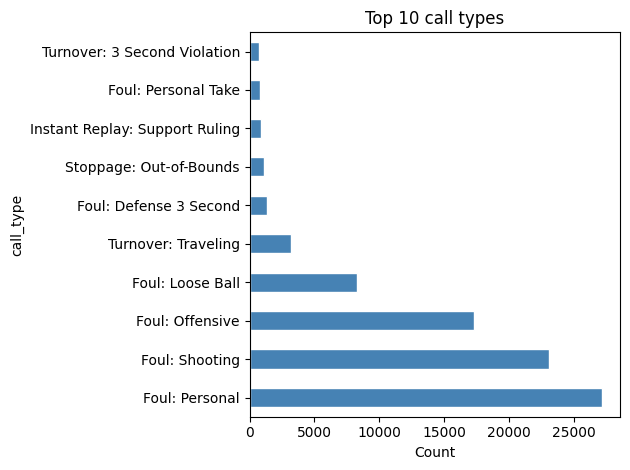

In [18]:
nba_data['call_type'].value_counts().head(10).plot(
    kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 call types')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

* **Home group**: `home`, `home_team`, `HomeTeamId`, `home_score` — abbreviation, nickname, and API identifier for the home team.
home: home team abbreviation  
home_score: home final score from the L2M reports, incomplete variable  
home_team: home team nickname  

In [19]:
# Home group — abbreviation, full nickname, score and API identifier
print("Data types:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['home', 'home_team', 'home_score', 'HomeTeamId']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
for pair in [('home', 'home_team'), ('home', 'HomeTeamId')]:
    subset = nba_data[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(nba_data[['home', 'home_team', 'HomeTeamId']].drop_duplicates().sort_values('home').head(10))

Data types:
  home: object
  home_team: object
  home_score: int64
  HomeTeamId: float64

Coverage per column:
  home: 90302 / 90302 (100.0%)
  home_team: 90302 / 90302 (100.0%)
  home_score: 90302 / 90302 (100.0%)
  HomeTeamId: 58270 / 90302 (64.5%)

Unique values:
  home: 30
  home_team: 30
  home_score: 81
  HomeTeamId: 30

Chi-squared test:
  home vs home_team: chi2=2618758.0, p=0.00e+00, dof=841
  home vs HomeTeamId: chi2=1689830.0, p=0.00e+00, dof=841

Sample mapping:
      home home_team    HomeTeamId
34000  ATL     Hawks  1.610613e+09
66     ATL     Hawks           NaN
33003  BKN      Nets  1.610613e+09
43     BKN      Nets           NaN
32723  BOS   Celtics  1.610613e+09
21     BOS   Celtics           NaN
77     CHA   Hornets           NaN
33556  CHA   Hornets  1.610613e+09
88     CHI     Bulls           NaN
31955  CHI     Bulls  1.610613e+09


> **Home group** --- The home group contains four columns. `home` (object) and `home_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$) --- one is fully determined by the other. `HomeTeamId` (float64) is the NBA API numeric identifier with 32,032 missing values (35.5%) corresponding to PDF-sourced games, but is significantly associated with `home` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `home_score` (int64) has complete coverage (100%) and 81 unique values --- not redundant with the identifier columns and retained for in-game context analysis. `home` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. `home_team` is retained as an auxiliary identifier. `HomeTeamId` is dropped --- structurally incomplete and redundant with `home`.

* **Away group**: `away`, `away_team`, `AwayTeamId` — same structure for the away team.  
away: away team abbreviation  
away_score: away final score from the L2M reports, incomplete variable  
away_team: away team nickname  
AwayTeamId: from official API  


In [20]:
# Away group — abbreviation, full nickname, score and API identifier
print("Data types:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['away', 'away_team', 'away_score', 'AwayTeamId']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
for pair in [('away', 'away_team'), ('away', 'AwayTeamId')]:
    subset = nba_data[[pair[0], pair[1]]].dropna()
    ct = pd.crosstab(subset[pair[0]], subset[pair[1]])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"  {pair[0]} vs {pair[1]}: chi2={chi2:.1f}, p={p:.2e}, dof={dof}")

print("\nSample mapping:")
print(nba_data[['away', 'away_team', 'AwayTeamId']].drop_duplicates().sort_values('away').head(10))

Data types:
  away: object
  away_team: object
  away_score: int64
  AwayTeamId: float64

Coverage per column:
  away: 90302 / 90302 (100.0%)
  away_team: 90302 / 90302 (100.0%)
  away_score: 90302 / 90302 (100.0%)
  AwayTeamId: 58270 / 90302 (64.5%)

Unique values:
  away: 30
  away_team: 30
  away_score: 79
  AwayTeamId: 30

Chi-squared test:
  away vs away_team: chi2=2618758.0, p=0.00e+00, dof=841
  away vs AwayTeamId: chi2=1689830.0, p=0.00e+00, dof=841

Sample mapping:
      away away_team    AwayTeamId
32120  ATL     Hawks  1.610613e+09
230    ATL     Hawks           NaN
32622  BKN      Nets  1.610613e+09
788    BKN      Nets           NaN
32322  BOS   Celtics  1.610613e+09
863    BOS   Celtics           NaN
875    CHA   Hornets           NaN
32099  CHA   Hornets  1.610613e+09
310    CHI     Bulls           NaN
34229  CHI     Bulls  1.610613e+09


> **Away group** --- The away group mirrors the home group exactly. `away` (object) and `away_team` (object) both have complete coverage (100%) and are significantly associated ($\chi^2 = 2{,}618{,}758$, $p < 0.001$). `AwayTeamId` (float64) has 32,032 missing values (35.5%) --- absent for PDF-sourced games --- and is significantly associated with `away` where non-missing ($\chi^2 = 1{,}689{,}830$, $p < 0.001$). `away_score` (int64) has complete coverage and 79 unique values --- retained for in-game context analysis. `away` is retained as the primary team identifier (abbreviation format) for merging with the betting dataset. `away_team` is retained as an auxiliary identifier. `AwayTeamId` is dropped --- structurally incomplete and redundant with `away`.

* **Committing group**: `committing_min`, `committing_team`, `committing_side` — attributes of the player committing the infraction.  
committing: committing player or team of the graded infraction in L2M, may be blank  
committing_min: total minutes played by player committing action (note, may be NA because the player did not play and likely an input error from NBA on L2M)  
committing_side: home/away for committing player  
committing_team: team for committing player  

In [21]:
# Committing group
print("Data types:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['committing_team', 'committing_side', 'committing_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['committing_team', 'committing_side']].dropna()
ct = pd.crosstab(subset['committing_team'], subset['committing_side'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  committing_team vs committing_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['committing_team', 'committing_side', 'home_team']].dropna().head(10))

Data types:
  committing_team: object
  committing_side: object
  committing_min: float64

Coverage per column:
  committing_team: 87869 / 90302 (97.3%)
  committing_side: 87869 / 90302 (97.3%)
  committing_min: 87119 / 90302 (96.5%)

Unique values:
  committing_team: 30
  committing_side: 2
  committing_min: 2536

Chi-squared test:
  committing_team vs committing_side: chi2=224.4, p=0.0000, dof=29

Sample:
   committing_team committing_side home_team
0              HOU            home   Rockets
1              CLE            away   Rockets
2              HOU            home   Rockets
3              HOU            home   Rockets
4              CLE            away   Rockets
5              HOU            home   Rockets
6              CLE            away   Rockets
8              CLE            away   Rockets
9              CLE            away   Rockets
10             HOU            home   Rockets


> **Committing group** --- The committing group contains three columns. `committing_team` (object) and `committing_side` (object) have identical coverage (97.3%, 2,433 missing). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `committing_team` identifies the specific franchise while `committing_side` encodes the relative position (home/away) which changes with each game. `committing_min` (float64) records minutes played by the committing player (96.5% coverage) and is dropped. `committing_team` is retained for potential team-level analysis. `committing_side` is retained as the core variable for $\beta$ and $\delta$ calculation. The treatment of 2,433 missing values is deferred.

In [22]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

Unique values:
['home' 'away' nan]

Missing: 2433

committing_side
away    44183
home    43686
NaN      2433
Name: count, dtype: int64


> **committing_side distribution** --- The `committing_side` column identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, it is the core column for calculating $\beta$ and $\delta$ as defined in Section 3.3. The column takes two clean values: `home` and `away`, with 2,433 missing values (2.7%). The distribution is nearly balanced --- 44,183 away (49.9%) and 43,686 home (49.4%) --- which is expected as there is no a priori reason for one side to commit more infractions. Missing values will be examined in the Tidy Data Preparation section.

* **Disadvantaged group**: `disadvantaged_min`, `disadvantaged_team`, `disadvantaged_side` — attributes of the player disadvantaged by the infraction.  
disadvantaged_min: total minutes played by player disadvantaged by action  
disadvantaged_side: home/away for disadvantaged player  
disadvantaged_team: team for disadvantaged player  

In [23]:
# Disadvantaged group
print("Data types:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].dtype}")

print("\nCoverage per column:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].notna().sum()} / {len(nba_data)} ({nba_data[col].notna().mean():.1%})")

print("\nUnique values:")
for col in ['disadvantaged_team', 'disadvantaged_side', 'disadvantaged_min']:
    print(f"  {col}: {nba_data[col].nunique()}")

print("\nChi-squared test:")
subset = nba_data[['disadvantaged_team', 'disadvantaged_side']].dropna()
ct = pd.crosstab(subset['disadvantaged_team'], subset['disadvantaged_side'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"  disadvantaged_team vs disadvantaged_side: chi2={chi2:.1f}, p={p:.4f}, dof={dof}")

print("\nSample:")
print(nba_data[['disadvantaged_team', 'disadvantaged_side', 'home_team']].dropna().head(10))

Data types:
  disadvantaged_team: object
  disadvantaged_side: object
  disadvantaged_min: float64

Coverage per column:
  disadvantaged_team: 84501 / 90302 (93.6%)
  disadvantaged_side: 84501 / 90302 (93.6%)
  disadvantaged_min: 78621 / 90302 (87.1%)

Unique values:
  disadvantaged_team: 30
  disadvantaged_side: 2
  disadvantaged_min: 2426

Chi-squared test:
  disadvantaged_team vs disadvantaged_side: chi2=224.4, p=0.0000, dof=29

Sample:
   disadvantaged_team disadvantaged_side home_team
0                 CLE               away   Rockets
1                 HOU               home   Rockets
2                 CLE               away   Rockets
3                 CLE               away   Rockets
4                 HOU               home   Rockets
5                 CLE               away   Rockets
6                 HOU               home   Rockets
8                 HOU               home   Rockets
9                 HOU               home   Rockets
10                CLE               away   Roc

> **Disadvantaged group** --- The disadvantaged group mirrors the committing group structurally. `disadvantaged_team` (object) and `disadvantaged_side` (object) have identical coverage (93.6%, 5,801 missing --- notably more than committing, 2,433). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `disadvantaged_team` identifies the specific franchise while `disadvantaged_side` encodes the relative position (home/away). `disadvantaged_min` (float64) records minutes played by the disadvantaged player (87.1% coverage) and is dropped. `disadvantaged_team` is retained for potential team-level analysis. `disadvantaged_side` is retained as a core variable for $\beta$ and $\delta$ calculation. The treatment of 5,801 missing values is deferred.

In [24]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

Unique values:
['away' 'home' nan]

Missing: 5801

disadvantaged_side
home    42428
away    42073
NaN      5801
Name: count, dtype: int64


> **Disadvantaged group** --- The disadvantaged group mirrors the committing group structurally. `disadvantaged_team` (object) and `disadvantaged_side` (object) have identical coverage (93.6%, 5,801 missing --- notably more than committing, 2,433). Chi-squared test shows a statistically significant but weak association ($\chi^2 = 224.4$, $p < 0.001$, $dof = 29$) --- they are not redundant. `disadvantaged_team` identifies the specific franchise while `disadvantaged_side` encodes the relative position (home/away). `disadvantaged_min` (float64) records minutes played by the disadvantaged player (87.1% coverage) and is dropped. `disadvantaged_team` is retained for potential team-level analysis. `disadvantaged_side` is retained as a core variable for $\beta$ and $\delta$ calculation. The treatment of 5,801 missing values is deferred.

* **Decision column** --- the core variable of the analysis. The distribution of values is examined to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded. `decision` takes four values: **CC** (Correct Call), **CNC** (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call).

In [25]:
print(nba_data['decision'].value_counts(dropna=False))

decision
CNC    60590
CC     21023
INC     5391
NaN     2502
IC       796
Name: count, dtype: int64


The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

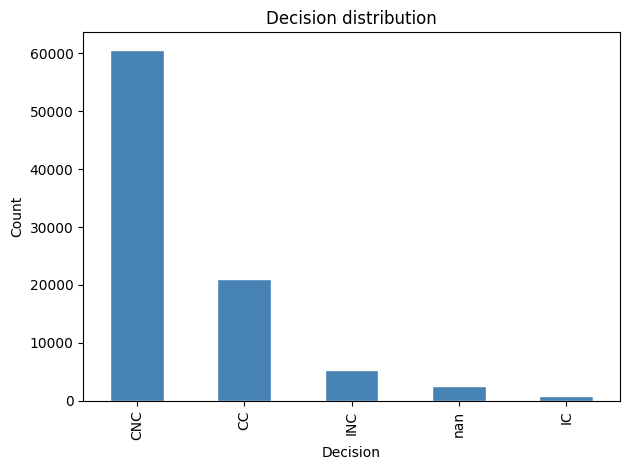

In [26]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The `decision` column is the core variable of the analysis. It takes four values: CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call). A fifth value — blank (NaN) — indicates plays not detectable without technology.

The distribution shows that CNC accounts for 60,590 entries (67.2% of all rows), followed by CC (21,023), INC (5,391), NaN (2,502), and IC (796). Pelechrinis (2023) notes that CNC criteria changed across seasons — during the 2015 season there were 6.4 CNC entries per game, while during the 2022 season there were almost 14 [PelechrinisL2M]. This inconsistency makes CNC unsuitable for longitudinal analysis. NaN entries are also excluded as they represent plays not detectable without technology. The working dataset therefore consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

* **Season column** --- the distribution of rows by season is examined to confirm coverage and identify any gaps.

In [27]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

season
2015    139
2016    439
2017    428
2018    475
2019    455
2020    395
2021    406
2022    442
2023    474
2024    411
2025    423
Name: gid, dtype: int64


2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes), which represents approximately 35–40% of all regular season games. A standard NBA season has 1,230 games (30 teams × 82 games / 2) [AtlhawksfanaticL2M].

In [28]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

season
2015    14.2
2016    15.6
2017    17.6
2018    22.3
2019    25.1
2020    20.8
2021    19.5
2022    20.0
2023    24.3
2024    20.1
2025    16.9
dtype: float64


2019 peaks at 25.1 actions per game — the highest in the dataset. 2019 has more rows than 2018 despite fewer games (455 vs 475): the average actions per game in 2019 is 25.1 — the highest in the dataset — compared to the 2018 value shown above.

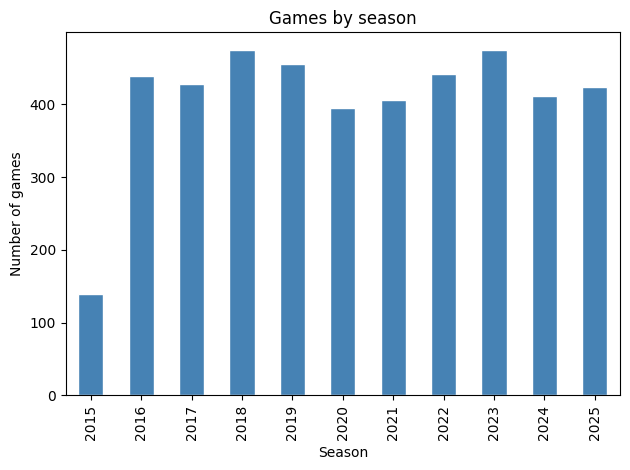

In [29]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

* **Playoff column** --- the split between regular season and playoff games is examined. Dummy variable equal to `True` if the game occurred in the playoffs.

In [30]:
games = nba_data.drop_duplicates(subset='gid')

print('Unique values:')
print(games['playoff'].unique())
print()
print('Missing:', games['playoff'].isnull().sum())
print()
print(games['playoff'].value_counts())
print(f'Total games: {len(games)}')

Unique values:
[False  True]

Missing: 0

playoff
False    4191
True      296
Name: count, dtype: int64
Total games: 4487


> **Playoff column** --- The `playoff` column is a boolean variable with no missing values. At the game level ($4{,}487$ unique games), 4,191 games (93.4%) are regular season and 296 games (6.6%) are playoff games. The column is used for period segmentation in the auxiliary hypothesis and will be converted to integer (0/1) if required by specific statistical procedures.

* **Attendance column** --- The range and distribution of values are examined, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing --- the range of attendance values and missing entries are identified.

In [31]:
print('Unique values:')
print(nba_data['ATTENDANCE'].unique())
print()
print('Missing:', nba_data['ATTENDANCE'].isnull().sum())
print()
print(nba_data['ATTENDANCE'].value_counts(dropna=False))

Unique values:
[18345. 18624. 13109. ... 19734. 19932. 17561.]

Missing: 6509

ATTENDANCE
NaN        6509
18997.0    2345
19800.0    2119
19600.0    1968
19812.0    1752
           ... 
21749.0       4
18434.0       4
14629.0       4
17831.0       2
15393.0       1
Name: count, Length: 2176, dtype: int64


Distribution --- the attendance distribution is visualized to identify patterns and anomalies.

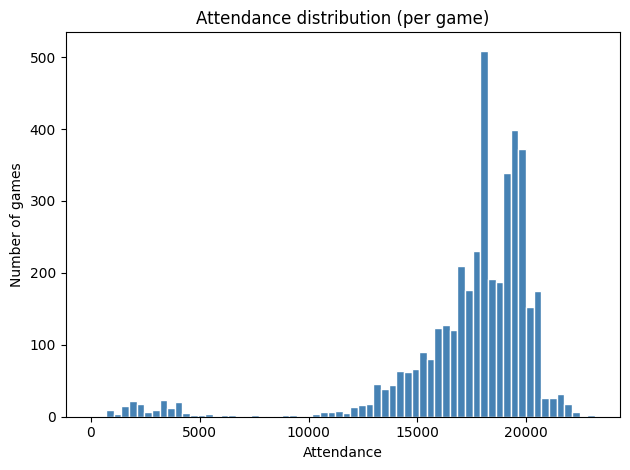

In [32]:
nba_data.drop_duplicates(subset='gid')['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

Low attendance investigation --- the histogram shows a small group below 5,000. The seasons these belong to are identified below.

In [33]:
print('Rows with ATTENDANCE < 5000:')
print(nba_data[nba_data['ATTENDANCE'] < 5000]['season'].value_counts().sort_index())

Rows with ATTENDANCE < 5000:
season
2021    2864
2022      13
Name: count, dtype: int64


Zero attendance appears only in 2022, not in 2020. The NBA 2020 season was completed in a controlled bubble environment in Orlando — all games were recorded under a single venue and attendance was uniformly zero, but the ATTENDANCE column records this as missing rather than zero for that period. The structural absence of fans in 2020 is therefore real, but is captured by the season variable rather than `ATTENDANCE`.

In [34]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

Rows: 13, Unique games: 1
            gid  season home_team away_team        date               call_type decision  ATTENDANCE
59965  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59966  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59967  22100850    2022   Raptors   Nuggets  2022-02-12         Foul: Offensive      CNC         0.0
59968  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59969  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting       CC         0.0
59970  22100850    2022   Raptors   Nuggets  2022-02-12  Foul: Defense 3 Second      INC         0.0
59971  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Shooting      CNC         0.0
59972  22100850    2022   Raptors   Nuggets  2022-02-12          Foul: Personal      CNC         0.0
59973  22100850    2022   Raptors   Nuggets  2022-02-12          

The single 2022 game with restricted attendance is confirmed and 13 rows are verified to correspond to one game.

In [35]:
games = nba_data.drop_duplicates(subset='gid')
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

home_team
Bulls            21116.0
76ers            20319.5
Mavericks        20157.0
Knicks           19812.0
Raptors          19800.0
Heat             19600.0
Nuggets          19520.0
Cavaliers        19432.0
Trail Blazers    19393.0
Clippers         19060.0
Lakers           18997.0
Celtics          18624.0
Spurs            18354.0
Jazz             18306.0
Thunder          18203.0
Name: ATTENDANCE, dtype: float64


Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

In [36]:
def calc_entropy(series):
    counts = pd.cut(series, bins=20).value_counts()
    probs = counts / counts.sum()
    return stats.entropy(probs)

attendance_entropy = nba_data.drop_duplicates(subset='gid').groupby('season')['ATTENDANCE'].apply(
    lambda x: calc_entropy(x.dropna())
)

print(attendance_entropy)

season
2015    2.615408
2016    2.527409
2017    2.599285
2018    2.492446
2019    2.492698
2020    2.613304
2021    2.075035
2022    2.129570
2023    2.453236
2024    2.387664
2025    2.290795
Name: ATTENDANCE, dtype: float64


Pre-COVID seasons (2015–2020) show stable entropy between 2.49 and 2.61, reflecting the natural variation of normal game attendance. The COVID seasons (2021–2022) show a sharp drop to 2.07–2.13, consistent with restricted capacity games clustering around a narrow range of low values. Post-COVID seasons (2023–2025) show partial recovery to 2.29–2.45, but have not returned to Pre-COVID levels. 

The entropy pattern suggests that `ATTENDANCE` may be more appropriately treated as a categorical variable than a continuous one, as it reflects arena capacity constraints and a structural break during the COVID period. This will be considered in the Tidy Data Preparation section.

> **Observation** — The `ATTENDANCE` column records the number of fans present at each game. It has 6,509 missing values (7.2%). The distribution clusters between 13,000–23,000, reflecting fixed arena capacities. Bulls lead with a median of 21,116, followed by 76ers (20,319) and Mavericks (20,157). A secondary cluster of 2,877 rows falls below 5,000 — 2,864 from the 2021 season played with restricted crowd capacity due to the COVID-19 pandemic, and 13 rows from a single Raptors vs Nuggets game (February 12, 2022) played without fans due to local public health restrictions. When analyzing the relationship between attendance and referee bias, the low-attendance group must be treated separately or controlled for via the `season` variable.

* **national_tv**: national TV network for the game, "no" indicates none

In [37]:
print('Unique values (per game):')
print(games['national_tv'].value_counts(dropna=False))
print()
print('Missing:', games['national_tv'].isnull().sum())
print(f'Total games: {len(games)}')

Unique values (per game):
national_tv
no                              3235
ESPN                             358
NBA TV                           355
TNT                              308
ABC                              114
NBATV                             36
TNT/truTV/Max                     32
TNT/truTV                         17
TNT OT                             9
TNT/Max                            6
ABC/ESPN+                          4
ESPN/ESPN2                         3
ABC/ESPN/ESPN+/Disney+             3
ABC/ESPN                           3
ESPN & ABC Simulcast               1
ESPN2                              1
ESPN 2                             1
ABC/ESPN/ESPN2/ESPN+/Disney+       1
Name: count, dtype: int64

Missing: 0
Total games: 4487


> **national_tv** --- The `national_tv` column identifies the national broadcast network for each game. It is a per-game attribute repeated for every row within a game, so the analysis is performed at the game level ($4{,}487$ unique games). There are no missing values. The majority of games were not nationally broadcast (3,235 games, 72.1%). Among nationally broadcast games, ESPN (358), NBA TV (355), and TNT (308) are the most frequent networks, followed by ABC (114). The remaining values represent multi-network simulcasts and variants. For analysis, `national_tv` is treated as a binary variable: `1` if the game was broadcast on any national network, and `0` otherwise. This binary grouping captures 1,252 nationally broadcast games (27.9%) versus 3,235 non-nationally broadcast games (72.1%).

* **Period column** --- the distribution of game periods is examined.

In [38]:
print('Period distribution:')
print(nba_data['period'].value_counts())

Period distribution:
period
Q4    78374
Q5    10533
Q6     1189
Q7      129
Q8       77
Name: count, dtype: int64


> **Period column** --- The `period` column identifies the game period of each graded play. The majority of plays occur in Q4 ($78{,}374$, 86.8%). Overtime periods Q5 through Q8 account for $11{,}928$ rows (13.2%), distributed across Q5 ($10{,}533$), Q6 ($1{,}189$), Q7 ($129$), and Q8 ($77$). Overtime games are included in the analysis as they represent close game situations where crowd pressure and referee bias are equally relevant.

##### **Ungrouped Column** 

Several columns are excluded from further analysis. `page` and `file` are PDF pipeline artifacts absent for all API-sourced games. `gcode` and `networks` duplicate information already captured by `gid` and `national_tv` respectively. The remaining 16 API-sourced columns (`PCTime`, `posID`, `posStart`, `posEnd`, `posTeamId`, `teamIdInFavor`, `errorInFavor`, `imgChart`, `GameId`, `GameDate`, `HomeTeamId`, `AwayTeamId`, `L2M_Comments`, `ImposibleIndicator`, `Difficulty`, `VideolLink`, `Qualifier`) have 32,032 or more missing values and are not used in the analysis.

`page` and `file` are described in the source documentation as PDF pipeline artifacts. `page` records the page number within the PDF report, while `file` stores the filename — either a `.pdf` file for archived seasons or a `.csv` file for API-sourced games. We verify their missingness pattern and content to confirm they carry no analytical value.

In [39]:
print("=== page ===")
print(f"Missing: {nba_data['page'].isna().sum()} ({nba_data['page'].isna().mean():.1%})")
print(f"Sample: {nba_data['page'].dropna().head(3).tolist()}")

print("\n=== file ===")
print(f"Missing: {nba_data['file'].isna().sum()} ({nba_data['file'].isna().mean():.1%})")
print(f"Unique: {nba_data['file'].nunique()}")
print(f"Sample PDF: {nba_data[nba_data['file'].str.endswith('.pdf', na=False)]['file'].iloc[0]}")
print(f"Sample API: {nba_data[nba_data['file'].str.endswith('.csv', na=False)]['file'].iloc[0]}")

=== page ===
Missing: 58270 (64.5%)
Sample: [1.0, 1.0, 1.0]

=== file ===
Missing: 0 (0.0%)
Unique: 4488
Sample PDF: L2M-CLE-HOU-3-1-15.pdf
Sample API: 0021800552.csv


> **Observation** — `page` has 58,270 missing values (64.5%) — absent for all API-sourced games as page numbers are only relevant for PDF reports. It carries no analytical value and is dropped. `file` has complete coverage (0 missing) with 4,488 unique values — one per game — but encodes the same game identity as `gid` in two different formats ('L2M-CLE-HOU-3-1-15.pdf' for PDF-sourced, '0021800552.csv' for API-sourced). `file` is redundant with `gid` and is dropped.

`networks` is described as a shorthand TV network identifier. We verify whether it is redundant with `national_tv` and examine its missingness pattern.

In [40]:
print("=== networks ===")
print(f"Missing: {nba_data['networks'].isna().sum()} ({nba_data['networks'].isna().mean():.1%})")
print(f"\nnetworks value counts:")
print(nba_data['networks'].value_counts(dropna=False))
print(f"\nnational_tv value counts (where networks notna):")
print(nba_data[nba_data['networks'].notna()]['national_tv'].value_counts(dropna=False))

=== networks ===
Missing: 88993 (98.6%)

networks value counts:
networks
NaN      88993
NBALP     1041
TNT        103
ABC         62
ESPN        57
NBATV       46
Name: count, dtype: int64

national_tv value counts (where networks notna):
national_tv
no       1041
TNT       103
ABC        62
ESPN       57
NBATV      46
Name: count, dtype: int64


> **Observation** — `networks` has 98.6% missing values (88,993 rows). Among the 1,309 non-missing rows, the mapping to `national_tv` is exact: `NBALP` (1,041) corresponds to `no` in `national_tv`, while `TNT` (103), `ABC` (62), `ESPN` (57), and `NBATV` (46) match directly. `networks` is structurally incomplete and fully redundant with `national_tv`. `networks` is dropped. `national_tv` is retained.

The remaining API-only columns are examined individually. `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing — no further analysis needed. For the remaining columns we examine missingness pattern, unique values, and relationship with analytical columns where relevant.

In [41]:
print("=== 100% missing ===")
for col in ['teamIdInFavor', 'errorInFavor', 'Qualifier']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%})")

print("\n=== ImposibleIndicator ===")
print(nba_data['ImposibleIndicator'].value_counts(dropna=False))

print("\n=== L2M_Comments ===")
print(nba_data['L2M_Comments'].value_counts(dropna=False))

print("\n=== Difficulty ===")
print(nba_data['Difficulty'].value_counts(dropna=False))
print()
print(pd.crosstab(nba_data['Difficulty'], nba_data['decision'], normalize='index').round(3))

print("\n=== posID, posStart, posEnd, imgChart, VideolLink ===")
for col in ['posID', 'posStart', 'posEnd', 'imgChart', 'VideolLink']:
    print(f"  {col}: missing={nba_data[col].isna().sum()} ({nba_data[col].isna().mean():.1%}), unique={nba_data[col].nunique()}")

print("\n=== posTeamId ===")
print(nba_data[['posTeamId', 'committing_team']].drop_duplicates().sort_values('committing_team'))
print(f"Unique posTeamId: {nba_data['posTeamId'].nunique()}")

=== 100% missing ===
  teamIdInFavor: missing=90302 (100.0%)
  errorInFavor: missing=90302 (100.0%)
  Qualifier: missing=90302 (100.0%)

=== ImposibleIndicator ===
ImposibleIndicator
0.0    58270
NaN    32032
Name: count, dtype: int64

=== L2M_Comments ===
L2M_Comments
NaN                                                                                                                                    89809
Due to a technical issue, video links for this report are not available at this time.                                                    203
NOTE: Due to a technical issue, video links may be unavailable.                                                                           72
NOTE: Due to technical issues, video is unavailable for this L2M report.                                                                  51
NOTE: Video and player names may be unavailable due to a technical issue.                                                                 46
NOTE: Due to a technical 

In [42]:
print(nba_data['posTeamId'].dropna().unique()[:10])
print(nba_data[['posTeamId', 'committing_team']].dropna().drop_duplicates('committing_team').sort_values('committing_team'))

[1.61061276e+09 1.61061276e+09 1.61061276e+09 1.61061276e+09
 1.61061274e+09 1.61061274e+09 1.61061274e+09 1.61061275e+09
 1.61061274e+09 1.61061275e+09]
          posTeamId committing_team
32120  1.610613e+09             ATL
32622  1.610613e+09             BKN
32323  1.610613e+09             BOS
32099  1.610613e+09             CHA
31955  1.610613e+09             CHI
32423  1.610613e+09             CLE
32297  1.610613e+09             DAL
31901  1.610613e+09             DEN
32081  1.610613e+09             DET
31924  1.610613e+09             GSW
31921  1.610613e+09             HOU
31956  1.610613e+09             IND
32349  1.610613e+09             LAC
31998  1.610613e+09             LAL
32373  1.610613e+09             MEM
32037  1.610613e+09             MIA
32192  1.610613e+09             MIL
32165  1.610613e+09             MIN
32394  1.610613e+09             NOP
31997  1.610613e+09             NYK
32012  1.610613e+09             OKC
32322  1.610613e+09             ORL
31870  1.610613e+0

> **Observation** — `teamIdInFavor`, `errorInFavor`, and `Qualifier` are 100% missing — never populated, dropped. `ImposibleIndicator` takes only one value (0.0) across all 58,270 non-null rows — carries no information, dropped. `L2M_Comments` is 99.5% missing and contains only technical notices about video availability — no analytical value, dropped. `Difficulty` shows a clear relationship with `decision` (Undetectable: 60% INC, Observable: 5.1% INC) suggesting it encodes call difficulty — a potential confounder. However, it has 37.8% missing values absent for all PDF-sourced games, making it structurally incomplete for the full dataset. `Difficulty` is dropped but noted as a limitation. `posTeamId` is a float64 NBA API team identifier with a one-to-one mapping to `committing_team` — redundant and 35.5% missing, dropped. `posID`, `posStart`, `posEnd`, `imgChart`, and `VideolLink` are all 35.5% missing — absent for all PDF-sourced games by design — and encode positional and video metadata not relevant to the analysis. All are dropped.

## 6. Limitations

Several limitations should be considered when interpreting the results.

The L2M dataset covers only close games — games within 5 points in the last two minutes. This introduces a selection bias: the sample is not representative of all NBA games, and findings may not generalize to non-close games.

The Monte Carlo simulation uses 10,000 runs, which produces stable empirical p-values for moderate effect sizes but may underestimate significance for very large effects (reporting p < 0.001 rather than exact values).

Multiple hypothesis tests are conducted without Bonferroni correction, following Pelechrinis (2023) [PelechrinisL2M], which increases the risk of Type I error inflation.

The COVID period (2021–2022) conflates two potentially distinct conditions — games with zero attendance and games with restricted capacity. These are treated as a single period for simplicity.

SRS from Basketball Reference is a season-level measure and does not capture within-season variation in team strength, unlike the game-level ELO ratings.

Player and referee names were excluded from the dataset on ethical grounds. As a result, player-level bias analysis relies on career-level PER groupings rather than individual identification, which limits the granularity of the findings.

## Reference

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y  
[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis  
[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M  
[FansidedNBA] FanSided. (2024). How many games are in the NBA season? https://fansided.com/posts/how-many-games-are-in-the-nba-season-01j8kcxt31rr  
[ErikstadJohansen2020] Erikstad, M. K., & Johansen, B. T. (2020). Referee bias in professional football: Favoritism toward successful teams in potential penalty situations. Frontiers in Sports and Active Living, 2, 19. https://doi.org/10.3389/fspor.2020.00019  
[Barrett2021] Barrett, D. (2021). Star player bias in the NBA: A quantile regression approach. Empirical Economics Bulletin, 14(1), 9. 
[Rothman1990] Rothman, K. J. (1990). No adjustments are needed for multiple  comparisons. Epidemiology, 1(1), 43–46. https://doi.org/10.1097/00001648-199001000-00010


